# CapitalSimulator: 原始社会早期 (M1)

本notebook演示M1里程碑：环境搭建 + 原始社会早期模拟。

In [ ]:
# Import required libraries
import sys
sys.path.insert(0, '..')

from src.model.model import CapitalModel
from src.model.ontology import MatterState
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

c:\Users\koltf\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 创建模型

In [ ]:
# Create the model with initial agents
model = CapitalModel(
    width=100,
    height=100,
    num_foragers=30,
    num_tribe_members=20
)

print(f"Model created with {model.get_population_count()} agents")
print(f"Social graph: {model.social_graph.graph.number_of_nodes()} nodes, {model.social_graph.graph.number_of_edges()} edges")

Model created with 50 agents
Social graph: 50 nodes, 6 edges


## 2. 运行模拟

In [ ]:
# Run simulation for 50 steps
STEPS = 50

for step in range(STEPS):
    model.step()
    if (step + 1) % 10 == 0:
        data = model.data_collector.get_latest()
        print(f"Step {step+1}: Population={data['total_population']}, "
              f"Subsistence={data['average_subsistence']:.2f}")

print("\nSimulation complete!")

Step 10: Population=50, Subsistence=0.92
Step 20: Population=47, Subsistence=0.95
Step 30: Population=47, Subsistence=0.94
Step 40: Population=46, Subsistence=0.95
Step 50: Population=46, Subsistence=0.95

Simulation complete!


## 3. 分析结果

C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\1051617425.py:24: UserWarning: Glyph 27963 (\N{CJK 

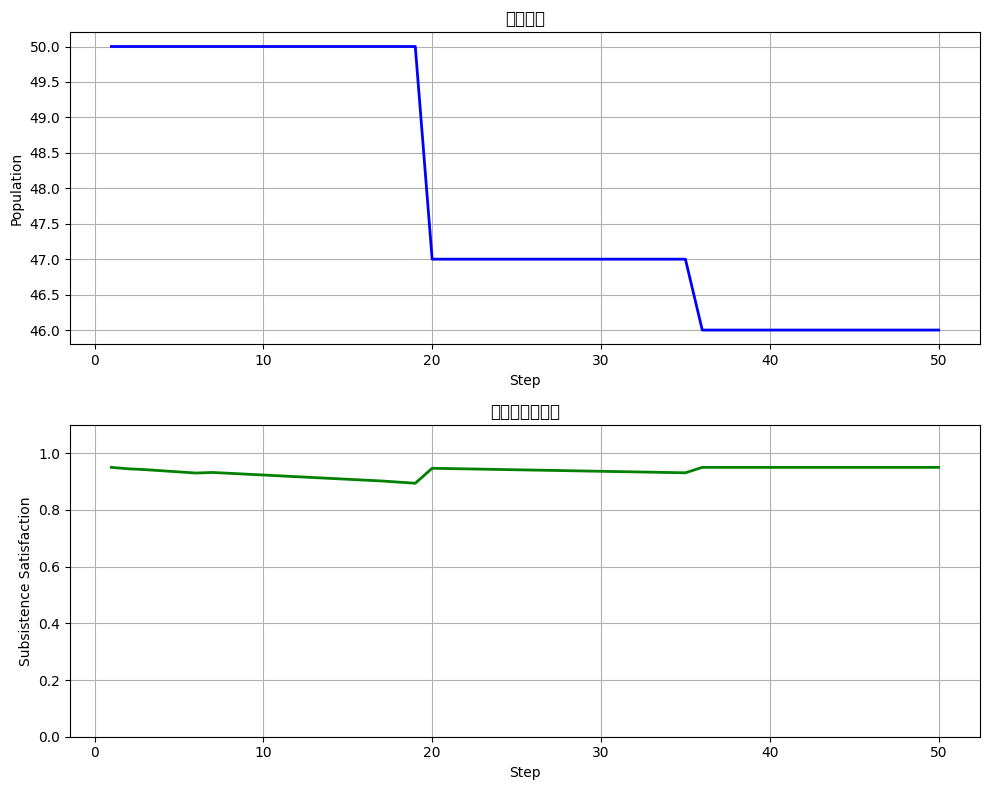

In [ ]:
# Get historical data
history = model.data_collector.get_history()

steps = [h['step'] for h in history]
population = [h['total_population'] for h in history]
subsistence = [h['average_subsistence'] for h in history]

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(steps, population, 'b-', linewidth=2)
ax1.set_xlabel('Step')
ax1.set_ylabel('Population')
ax1.set_title('人口变化')
ax1.grid(True)

ax2.plot(steps, subsistence, 'g-', linewidth=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Subsistence Satisfaction')
ax2.set_title('生活资料满足率')
ax2.set_ylim(0, 1.1)
ax2.grid(True)

plt.tight_layout()
plt.show()

## 4. 阶级分布

C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\koltf\AppData\Local\Temp\ipykernel_2536\3754105707.py:15: UserWarning: Glyph 24067 (\N{CJK 

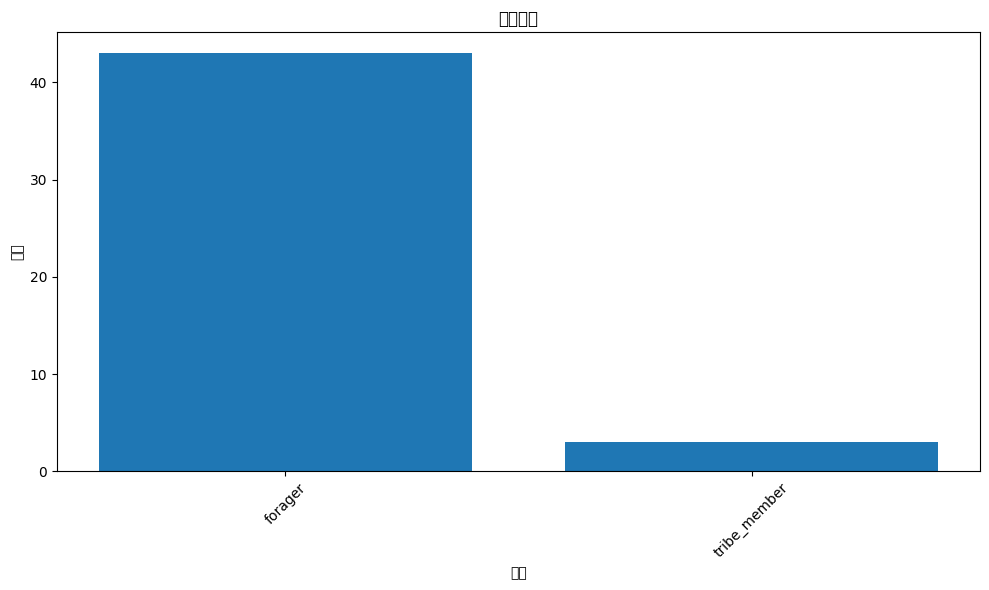

In [ ]:
# Get latest class distribution
latest = model.data_collector.get_latest()
class_dist = latest.get('class_distribution', {})

# Filter non-zero classes
non_zero = {k: v for k, v in class_dist.items() if v > 0}

if non_zero:
    plt.figure(figsize=(10, 6))
    plt.bar(non_zero.keys(), non_zero.values())
    plt.xlabel('阶级')
    plt.ylabel('人数')
    plt.title('阶级分布')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No class data available yet")

## 5. 社会关系图

In [ ]:
import networkx as nx

# Get edge types
edge_counts = model.social_graph.get_edge_count_by_type()
print("社会关系边类型统计:")
for edge_type, count in edge_counts.items():
    print(f"  {edge_type}: {count}")

社会关系边类型统计:
  kinship: 6


---

**M1 完成标志**:
- [x] 环境搭建完成
- [x] 原始社会早期模拟运行
- [x] 人口和满足率指标正常
- [ ] 下一阶段：涌现农业定居 (M2)